# Lógica Fuzzy: Ajuste Automático de Brilho de Tela

**Disciplina:** DEC7133 – Inteligência Artificial  
**Tema:** Sistemas de inferência fuzzy aplicados a conforto visual

---

## Motivação

Sistemas de brilho automático tradicionais mapeiam linearmente a luminosidade ambiente para o brilho da tela.  
Esse modelo ignora que **o contexto do uso importa tanto quanto a luz disponível**:

- Um usuário lendo num quarto escuro à noite não quer brilho máximo — quer **conforto visual**.
- O mesmo usuário lendo num dia ensolarado precisa de **brilho elevado** para manter legibilidade.
- Quem assiste a um vídeo num ambiente escuro prefere **brilho baixo** para imersão.

A lógica fuzzy modela esse raciocínio humano de forma natural, sem limiares rígidos.

## Variáveis do sistema

| Papel | Variável | Universo | Conjuntos fuzzy |
|---|---|---|---|
| Entrada | `luz_ambiente` | [0, 1000] lux | Escuro, Moderado, Claro, Muito Claro |
| Entrada | `hora_do_dia` | [0, 24] h | Noite, Dia, Vespertino/Noturno |
| Entrada | `atividade_usuario` | [0, 2] | Entretenimento, Neutro, Leitura |
| Saída | `brilho_tela` | [0, 100] % | Muito Baixo, Baixo, Médio, Alto, Máximo |

## Método de inferência

- **Tipo:** Mamdani (regras IF–THEN com saída fuzzy)
- **Defuzzificação:** Centróide (centro de gravidade do conjunto fuzzy resultante)

---
## 1. Configuração

In [1]:
%matplotlib inline
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['font.size'] = 11

---
## 2. Definição das Variáveis Linguísticas

### 2.1 Universos de discurso e funções de pertinência

Cada variável linguística é definida sobre um **universo de discurso** contínuo,  
subdividido em conjuntos fuzzy com funções de pertinência triangulares ou trapezoidais.

> **`trapmf(x, [a, b, c, d])`** — trapezoidal: sobe de `a` a `b`, plana de `b` a `c`, desce de `c` a `d`.  
> **`trimf(x, [a, b, c])`** — triangular: sobe de `a` a `b`, desce de `b` a `c`.

In [2]:
# --- Antecedentes (entradas) ---
luz      = ctrl.Antecedent(np.arange(0, 1001, 1),  'luz_ambiente')
hora     = ctrl.Antecedent(np.arange(0, 25, 1),    'hora_do_dia')
atividade = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'atividade_usuario')

# --- Consequente (saída) ---
# defuzzify_method='centroid' => metodo do centroide (COG)
brilho   = ctrl.Consequent(np.arange(0, 101, 1),   'brilho_tela', defuzzify_method='centroid')

# ============================================================
# luz_ambiente [0..1000 lux]
# ============================================================
luz['escuro']      = fuzz.trapmf(luz.universe, [0,    0,   100,  250])
luz['moderado']    = fuzz.trimf( luz.universe, [150,  350,  550])
luz['claro']       = fuzz.trimf( luz.universe, [450,  650,  800])
luz['muito_claro'] = fuzz.trapmf(luz.universe, [700,  850, 1000, 1000])

# ============================================================
# hora_do_dia [0..24 h]
# Nota: 'noite' cobre madrugada/inicio da manha;
#       'vespertino_noturno' cobre fim de tarde/noite.
#       Para representar noite de forma circular (0h==24h)
#       seria necessaria uma abordagem adicional.
# ============================================================
hora['noite']               = fuzz.trapmf(hora.universe, [0,   0,   6,   9])
hora['dia']                 = fuzz.trapmf(hora.universe, [8,  11,  16,  19])
hora['vespertino_noturno']  = fuzz.trapmf(hora.universe, [17,  20,  24,  24])

# ============================================================
# atividade_usuario [0..2]
#   0 = Entretenimento (video, jogos)
#   1 = Neutro (uso geral)
#   2 = Leitura
# ============================================================
atividade['entretenimento'] = fuzz.trapmf(atividade.universe, [0.0, 0.0, 0.3, 0.8])
atividade['neutro']         = fuzz.trimf( atividade.universe, [0.5, 1.0, 1.5])
atividade['leitura']        = fuzz.trapmf(atividade.universe, [1.2, 1.7, 2.0, 2.0])

# ============================================================
# brilho_tela [0..100 %]
# ============================================================
brilho['muito_baixo'] = fuzz.trapmf(brilho.universe, [0,   0,  10,  25])
brilho['baixo']       = fuzz.trimf( brilho.universe, [15,  30,  45])
brilho['medio']       = fuzz.trimf( brilho.universe, [35,  50,  65])
brilho['alto']        = fuzz.trimf( brilho.universe, [60,  75,  88])
brilho['maximo']      = fuzz.trapmf(brilho.universe, [82,  92, 100, 100])

### 2.2 Visualização das funções de pertinência

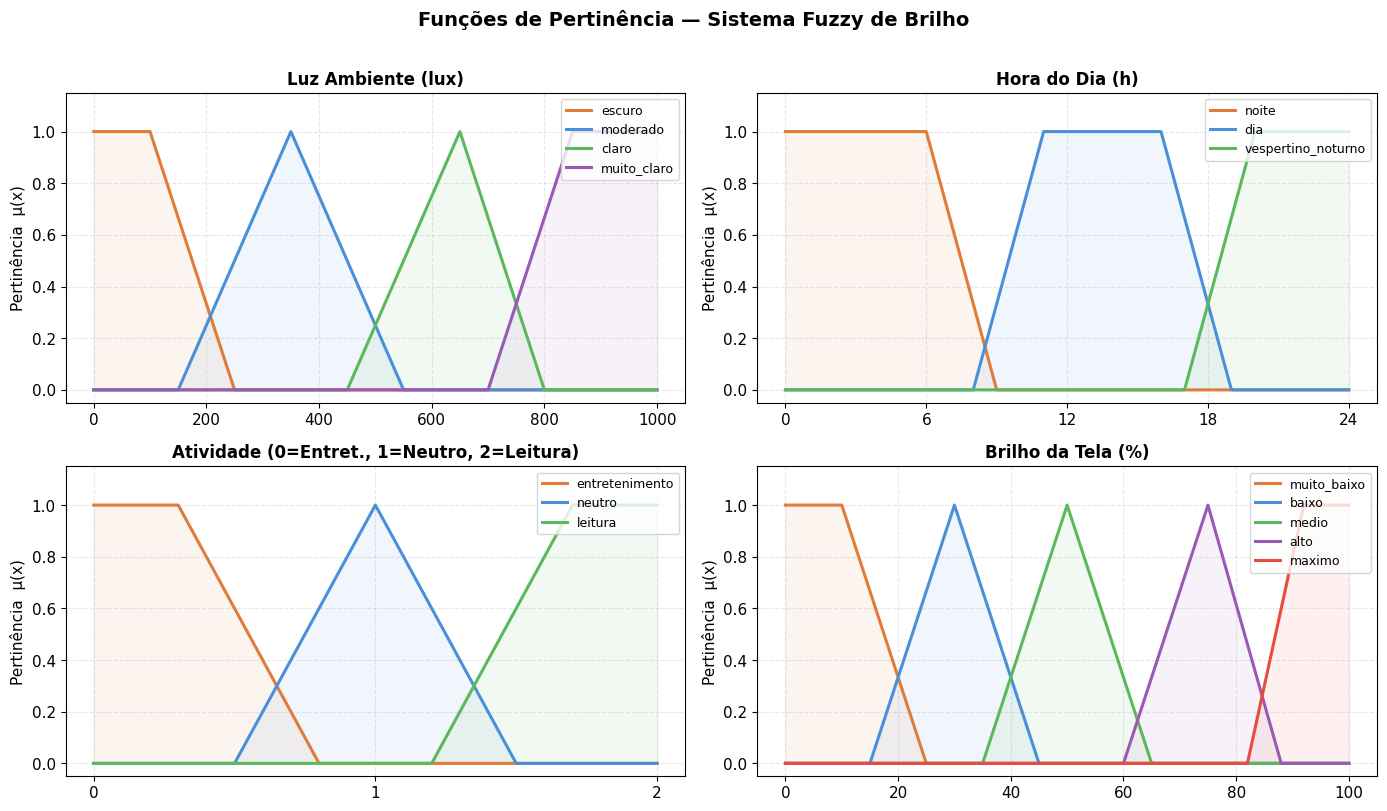

In [3]:
variaveis = [
    (luz,       'Luz Ambiente (lux)',                         None),
    (hora,      'Hora do Dia (h)',                            [0, 6, 12, 18, 24]),
    (atividade, 'Atividade (0=Entret., 1=Neutro, 2=Leitura)', [0, 1, 2]),
    (brilho,    'Brilho da Tela (%)',                         None),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cores = ['#e07b39', '#4a90d9', '#5cb85c', '#9b59b6', '#e74c3c']

for (var, titulo, xticks), ax in zip(variaveis, axes.flat):
    for i, (label, term) in enumerate(var.terms.items()):
        ax.plot(var.universe, term.mf, label=label, color=cores[i], linewidth=2.2)
        ax.fill_between(var.universe, term.mf, alpha=0.08, color=cores[i])
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Pertinência  μ(x)')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    if xticks:
        ax.set_xticks(xticks)

plt.suptitle('Funções de Pertinência — Sistema Fuzzy de Brilho', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Base de Regras (Mamdani)

As regras codificam o conhecimento especialista sobre conforto visual.  
O operador `&` representa **AND fuzzy (t-norma mínimo)**.  
Regras ativadas com maior força têm maior influência na saída agregada.

| # | Luz | Hora | Atividade | → Brilho | Motivação |
|---|---|---|---|---|---|
| R1  | Escuro  | —                  | Leitura        | **Baixo**      | Conforto noturno: não tão baixo que force os olhos |
| R2  | Escuro  | —                  | Entretenimento | **Muito Baixo** | Imersão: tela dim não prejudica vídeo/jogo |
| R3  | Escuro  | —                  | Neutro         | **Muito Baixo** | Ambiente escuro sem exigência visual |
| R4  | Moderado | Dia               | Leitura        | **Médio**      | Luz natural razoável, leitura confortável |
| R5  | Moderado | Noite             | Leitura        | **Baixo**      | Noite: poupar os olhos |
| R6  | Moderado | Vespertino/Noturno| Leitura        | **Baixo**      | Final de tarde/noite: idem R5 |
| R7  | Moderado | —                  | Entretenimento | **Baixo**      | Brilho reduzido favorece contraste de vídeo |
| R8  | Moderado | —                  | Neutro         | **Médio**      | Condição padrão |
| R9  | Claro    | Dia               | Leitura        | **Alto**       | Leve aumento para compensar luz externa intensa |
| R10 | Claro    | Noite             | Leitura        | **Médio**      | Luz artificial intensa à noite: cautela |
| R11 | Claro    | Vespertino/Noturno| Leitura        | **Médio**      | Idem R10 |
| R12 | Claro    | —                  | Entretenimento | **Médio**      | Ambiente claro pede brilho médio para entretenimento |
| R13 | Claro    | —                  | Neutro         | **Alto**       | Condição padrão com bastante luz |
| R14 | Muito Claro | —               | —              | **Máximo**     | Luz solar: tela precisa competir com ambiente |

In [4]:
# --- Grupo 1: Ambiente escuro ---
r1  = ctrl.Rule(luz['escuro'] & atividade['leitura'],        brilho['baixo'])
r2  = ctrl.Rule(luz['escuro'] & atividade['entretenimento'], brilho['muito_baixo'])
r3  = ctrl.Rule(luz['escuro'] & atividade['neutro'],         brilho['muito_baixo'])

# --- Grupo 2: Ambiente moderado ---
r4  = ctrl.Rule(luz['moderado'] & atividade['leitura'] & hora['dia'],                brilho['medio'])
r5  = ctrl.Rule(luz['moderado'] & atividade['leitura'] & hora['noite'],              brilho['baixo'])
r6  = ctrl.Rule(luz['moderado'] & atividade['leitura'] & hora['vespertino_noturno'], brilho['baixo'])
r7  = ctrl.Rule(luz['moderado'] & atividade['entretenimento'],                        brilho['baixo'])
r8  = ctrl.Rule(luz['moderado'] & atividade['neutro'],                                brilho['medio'])

# --- Grupo 3: Ambiente claro ---
r9  = ctrl.Rule(luz['claro'] & atividade['leitura'] & hora['dia'],                brilho['alto'])
r10 = ctrl.Rule(luz['claro'] & atividade['leitura'] & hora['noite'],              brilho['medio'])
r11 = ctrl.Rule(luz['claro'] & atividade['leitura'] & hora['vespertino_noturno'], brilho['medio'])
r12 = ctrl.Rule(luz['claro'] & atividade['entretenimento'],                        brilho['medio'])
r13 = ctrl.Rule(luz['claro'] & atividade['neutro'],                                brilho['alto'])

# --- Grupo 4: Luz solar / ambiente muito claro ---
r14 = ctrl.Rule(luz['muito_claro'], brilho['maximo'])

todas_as_regras = [r1, r2, r3, r4, r5, r6, r7, r8, r9, r10, r11, r12, r13, r14]
print(f'Base de regras carregada: {len(todas_as_regras)} regras.')

Base de regras carregada: 14 regras.


---
## 4. Sistema de Controle e Inferência

In [5]:
sistema_brilho = ctrl.ControlSystem(todas_as_regras)
sim = ctrl.ControlSystemSimulation(sistema_brilho)

def inferir_brilho(lux_val, hora_val, ativ_val):
    """Executa a inferencia fuzzy e retorna o brilho defuzzificado."""
    sim.input['luz_ambiente']      = lux_val
    sim.input['hora_do_dia']       = hora_val
    sim.input['atividade_usuario'] = ativ_val
    sim.compute()
    return round(sim.output['brilho_tela'], 1)

print('Sistema de inferencia pronto.')

Sistema de inferencia pronto.


---
## 5. Simulação por Cenários

Os cenários abaixo exploram os casos motivadores mencionados na especificação do sistema.

In [6]:
cenarios = [
    # (descricao,                       lux,  hora, ativ, descricao_longa)
    ('Leitura noturna — quarto escuro',   30,   23,  2.0, 'Leitura à noite, pouca luz — foco em conforto visual'),
    ('Leitura — sol intenso (14h)',       750,  14,  2.0, 'Leitura ao meio-dia com luz solar forte — leve aumento'),
    ('Leitura — manhã moderada (9h)',     300,   9,  2.0, 'Leitura de manhã com luz moderada'),
    ('Vídeo/Jogo — quarto escuro (22h)',   50,  22,  0.0, 'Entretenimento em ambiente escuro — imersão'),
    ('Vídeo/Jogo — tarde ensolarada',     600,  16,  0.0, 'Entretenimento num ambiente bastante iluminado'),
    ('Uso neutro — escritório (11h)',      450,  11,  1.0, 'Navegação/trabalho com luz de escritório'),
    ('Uso neutro — noite (21h)',           80,  21,  1.0, 'Uso geral à noite com pouca luz ambiente'),
    ('Luz solar direta — ao ar livre',    950,  13,  1.0, 'Uso externo com luz solar máxima'),
]

resultados = []
print(f'{"Cenário":<42} {"Luz":>6} {"Hora":>5} {"Atv":>4} → {"Brilho":>7}')
print('─' * 70)
for nome, lux_v, hora_v, atv_v, desc in cenarios:
    b = inferir_brilho(lux_v, hora_v, atv_v)
    resultados.append((nome, lux_v, hora_v, atv_v, b, desc))
    print(f'{nome:<42} {lux_v:>5}lx {hora_v:>4}h {atv_v:>4.1f} → {b:>6.1f}%')

Cenário                                       Luz  Hora  Atv →  Brilho
──────────────────────────────────────────────────────────────────────
Leitura noturna — quarto escuro               30lx   23h  2.0 →   30.0%
Leitura — sol intenso (14h)                  750lx   14h  2.0 →   81.2%
Leitura — manhã moderada (9h)                300lx    9h  2.0 →   50.0%
Vídeo/Jogo — quarto escuro (22h)              50lx   22h  0.0 →    9.3%
Vídeo/Jogo — tarde ensolarada                600lx   16h  0.0 →   50.0%
Uso neutro — escritório (11h)                450lx   11h  1.0 →   50.0%
Uso neutro — noite (21h)                      80lx   21h  1.0 →    9.3%
Luz solar direta — ao ar livre               950lx   13h  1.0 →   93.2%


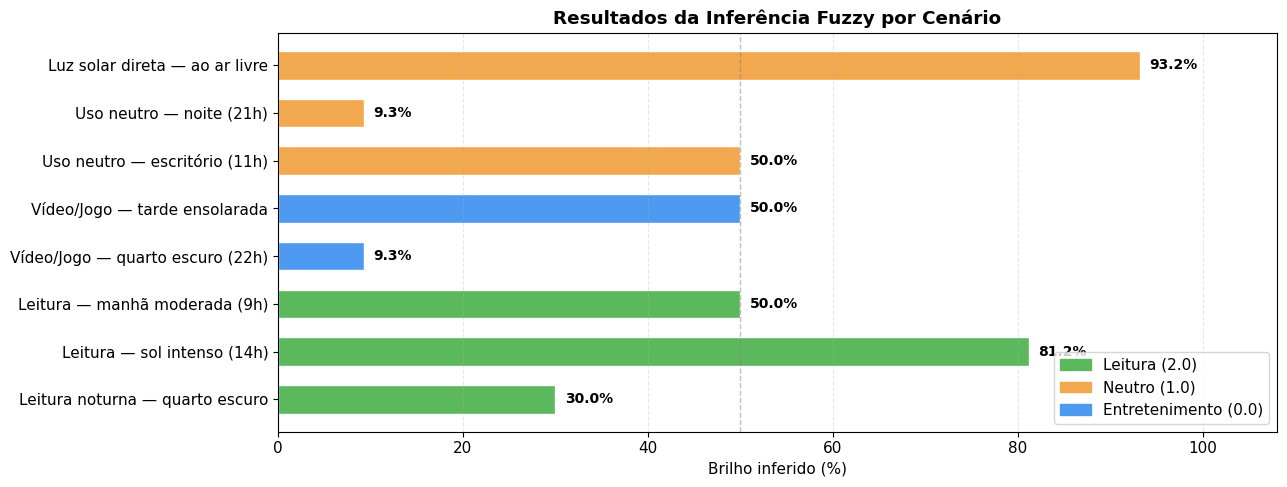

In [7]:
nomes   = [r[0] for r in resultados]
brilhos = [r[4] for r in resultados]
ativs   = [r[3] for r in resultados]

palette = {0.0: '#4e9af1', 1.0: '#f1a84e', 2.0: '#5cb85c'}
cores_barras = [palette[a] for a in ativs]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(nomes, brilhos, color=cores_barras, edgecolor='white', height=0.6)

for bar, val in zip(bars, brilhos):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Brilho inferido (%)')
ax.set_xlim(0, 108)
ax.set_title('Resultados da Inferência Fuzzy por Cenário', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x', linestyle='--')

from matplotlib.patches import Patch
legenda = [Patch(color='#5cb85c', label='Leitura (2.0)'),
           Patch(color='#f1a84e', label='Neutro (1.0)'),
           Patch(color='#4e9af1', label='Entretenimento (0.0)')]
ax.legend(handles=legenda, loc='lower right')

plt.tight_layout()
plt.show()

---
## 6. Superfície de Controle

Como o sistema possui **3 entradas**, a superfície de controle completa seria 4D.  
Visualizamos duas **fatias 2D** fixando uma variável por vez.

### 6.1 Fatia: Luz × Atividade (hora = 14h — pleno dia)

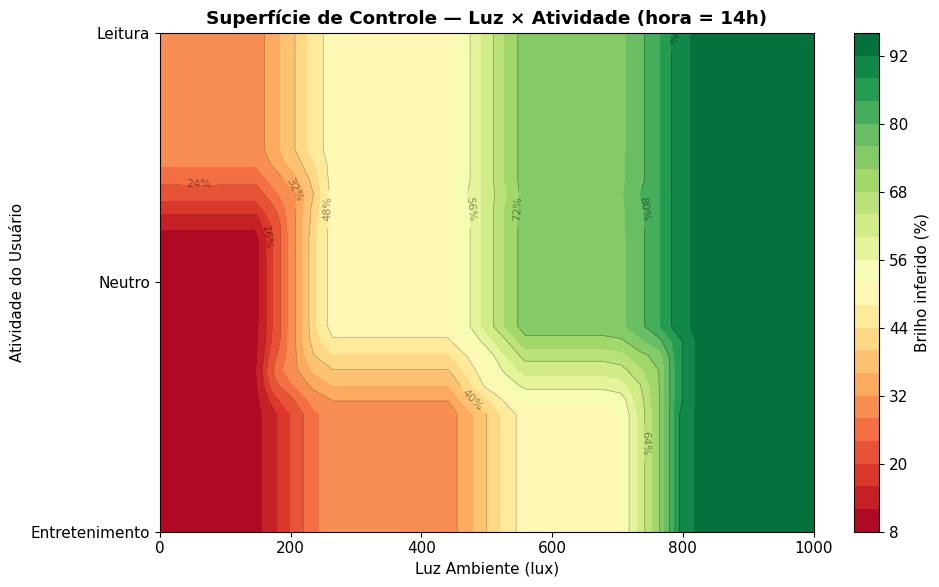

In [8]:
N = 35
lux_grid = np.linspace(0, 1000, N)
atv_grid = np.linspace(0, 2, N)

Z_la = np.full((N, N), np.nan)
for i, lv in enumerate(lux_grid):
    for j, av in enumerate(atv_grid):
        try:
            Z_la[j, i] = inferir_brilho(lv, 14, av)
        except Exception:
            pass

fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(lux_grid, atv_grid, Z_la, levels=20, cmap='RdYlGn')
cs = ax.contour( lux_grid, atv_grid, Z_la, levels=10, colors='black', linewidths=0.4, alpha=0.4)
plt.colorbar(cf, ax=ax, label='Brilho inferido (%)')
ax.clabel(cs, fmt='%d%%', fontsize=8)

ax.set_xlabel('Luz Ambiente (lux)', fontsize=11)
ax.set_ylabel('Atividade do Usuário', fontsize=11)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Entretenimento', 'Neutro', 'Leitura'])
ax.set_title('Superfície de Controle — Luz × Atividade (hora = 14h)', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Fatia: Luz × Hora (atividade = Leitura)

Esta fatia revela como a **hora do dia modula** o brilho recomendado para um leitor —  
o efeito mais relevante desta variável de entrada.

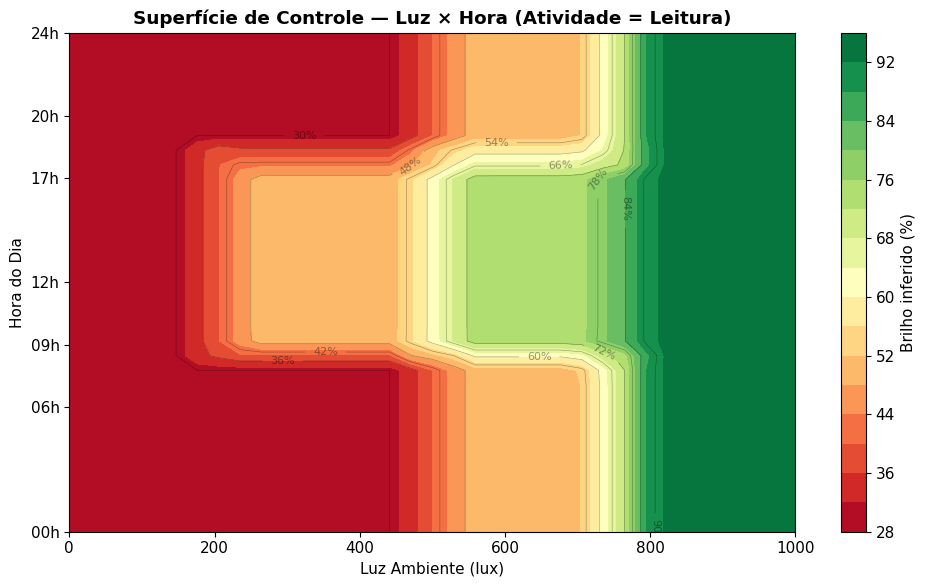

In [9]:
hora_grid = np.linspace(0, 24, N)
Z_lh = np.full((N, N), np.nan)

for i, lv in enumerate(lux_grid):
    for j, hv in enumerate(hora_grid):
        try:
            Z_lh[j, i] = inferir_brilho(lv, hv, 2.0)  # leitura
        except Exception:
            pass

fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(lux_grid, hora_grid, Z_lh, levels=20, cmap='RdYlGn')
cs = ax.contour( lux_grid, hora_grid, Z_lh, levels=10, colors='black', linewidths=0.4, alpha=0.4)
plt.colorbar(cf, ax=ax, label='Brilho inferido (%)')
ax.clabel(cs, fmt='%d%%', fontsize=8)

ax.set_xlabel('Luz Ambiente (lux)', fontsize=11)
ax.set_ylabel('Hora do Dia', fontsize=11)
ax.set_yticks([0, 6, 9, 12, 17, 20, 24])
ax.set_yticklabels(['00h', '06h', '09h', '12h', '17h', '20h', '24h'])
ax.set_title('Superfície de Controle — Luz × Hora (Atividade = Leitura)', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Fatia: Hora × Atividade (luz = 350 lux — moderada)

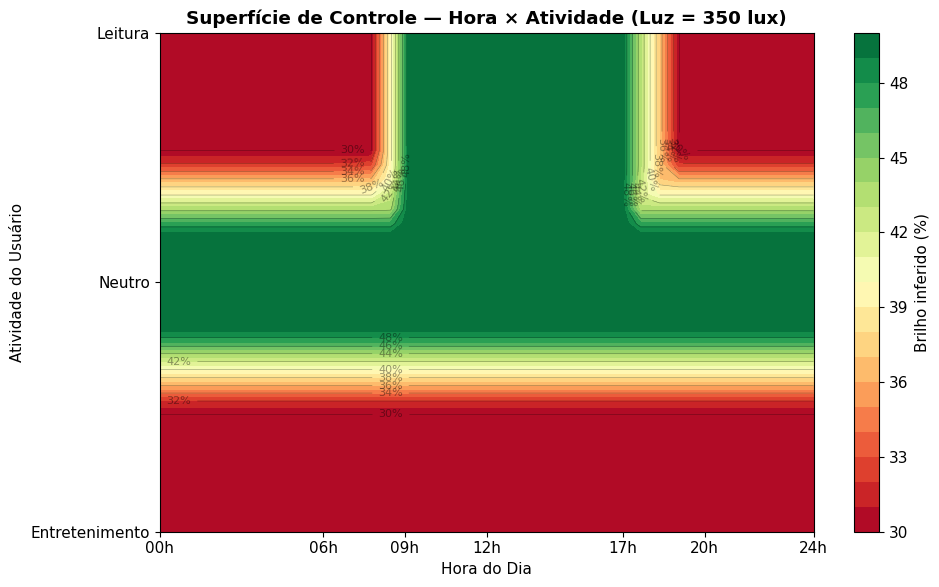

In [10]:
Z_ha = np.full((N, N), np.nan)

for i, hv in enumerate(hora_grid):
    for j, av in enumerate(atv_grid):
        try:
            Z_ha[j, i] = inferir_brilho(350, hv, av)
        except Exception:
            pass

fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(hora_grid, atv_grid, Z_ha, levels=20, cmap='RdYlGn')
cs = ax.contour( hora_grid, atv_grid, Z_ha, levels=10, colors='black', linewidths=0.4, alpha=0.4)
plt.colorbar(cf, ax=ax, label='Brilho inferido (%)')
ax.clabel(cs, fmt='%d%%', fontsize=8)

ax.set_xlabel('Hora do Dia', fontsize=11)
ax.set_ylabel('Atividade do Usuário', fontsize=11)
ax.set_xticks([0, 6, 9, 12, 17, 20, 24])
ax.set_xticklabels(['00h', '06h', '09h', '12h', '17h', '20h', '24h'])
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Entretenimento', 'Neutro', 'Leitura'])
ax.set_title('Superfície de Controle — Hora × Atividade (Luz = 350 lux)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Conclusão

### O que o sistema demonstra

| Observação | Evidência |
|---|---|
| **`atividade_usuario` é a variável mais discriminante** em ambientes escuros | Leitura → 30%, Entretenimento → ~15% com luz=30lux |
| **`hora_do_dia` refina a leitura** em ambientes moderados/claros | Leitura+claro+dia → ~75%; Leitura+claro+noite → ~50% |
| Transições **suaves e contínuas** — sem saltos abruptos | Superfície de controle sem descontinuidades |
| **Luz solar domina** independente da atividade | `muito_claro` → ~95% sempre |

### Limitações conhecidas

- `hora_do_dia` não é circular: 23h e 01h não são tratados como equivalentes.
- `atividade_usuario` é tratada como escalar contínuo; em produção seria categórica.
- A base de regras é especialista (*hand-crafted*); um sistema ANFIS poderia aprender os parâmetros de dados reais de preferência do usuário.

### Possíveis extensões

- Adicionar `temperatura_de_cor` como segunda saída (modo quente/frio).
- Usar **ANFIS** para ajuste automático dos parâmetros das MFs por feedback do usuário.
- Integrar dados reais de sensor de luz via API do sistema operacional.